# Benchmarking spot counting using Vision Language Models

Now, we want to apply [moondream](https://huggingface.co/vikhyatk/moondream2) on different and potentially more challenging biological examples to see how it performs.

In [1]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from PIL import Image, ImageDraw
from image_utilities import numpy_to_bytestream, extract_json, generate_spots
from tqdm import tqdm
import stackview
from skimage import data
import numpy as np
from skimage import img_as_ubyte

In [2]:

model = AutoModelForCausalLM.from_pretrained(
    "vikhyatk/moondream2",
    revision="2025-01-09",
    trust_remote_code=True,
    # Comment to run on CPU. To use the GPU, you need about 5 GB of GPU Memory.
    # GPU "cuda"
    # On Apple Silicon, use "mps"
    device_map={"": "mps"}
)

## Cell nuclei


StackViewNDArray([[ 8868,  6923,  5690, ..., 13942, 12804, 14653],
                  [ 7113,  5501,  5216, ..., 16739, 13657, 15554],
                  [ 5833,  7160,  5928, ..., 15838, 16739, 17166],
                  ...,
                  [ 2513,  3936,  3414, ...,  3699,  4126,  4220],
                  [ 3319,  3272,  2513, ...,  3699,  3367,  2940],
                  [ 3130,  3794,  3225, ...,  2987,  3746,  4315]],
                 shape=(256, 256), dtype=uint16)
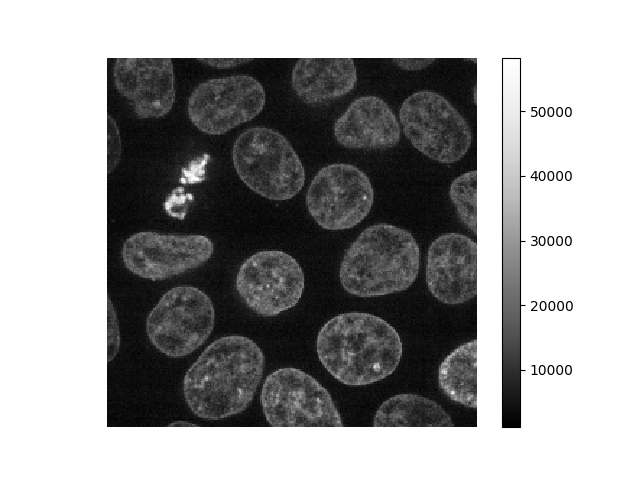
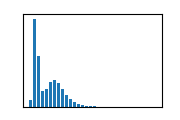

In [3]:
# Load the human mitosis dataset
nuclei = data.cells3d()[30, 1, :, :]

# Display the image
stackview.insight(nuclei)

In [4]:
nuclei_uint8 = img_as_ubyte(nuclei)
pil_nuclei = Image.fromarray(nuclei_uint8)

In [5]:
encoded_nuclei = model.encode_image(pil_nuclei)

In [6]:
# Pointing
print("\nPointing: 'bright spot'")
points_nuclei = model.point(encoded_nuclei, "Mark the large round nuclei in the image")["points"]
print(f"Found {len(points_nuclei)} bright spot(s)")


Pointing: 'bright spot'
Found 18 bright spot(s)


In [7]:
box_half_size_nuclei = 5 / nuclei_uint8.shape[0]
bb_nuclei = [{'x':p['x']-box_half_size_nuclei, 'y':p['y']-box_half_size_nuclei, 'width':2*box_half_size_nuclei, 'height':2*box_half_size_nuclei } for p in points_nuclei]

StackViewNDArray([[[34, 34, 34],
                   [26, 26, 26],
                   [20, 20, 20],
                   ...,
                   [57, 57, 57],
                   [52, 52, 52],
                   [60, 60, 60]],

                  [[26, 26, 26],
                   [19, 19, 19],
                   [18, 18, 18],
                   ...,
                   [69, 69, 69],
                   [56, 56, 56],
                   [64, 64, 64]],

                  [[20, 20, 20],
                   [26, 26, 26],
                   [21, 21, 21],
                   ...,
                   [65, 65, 65],
                   [69, 69, 69],
                   [72, 72, 72]],

                  ...,

                  [[ 5,  5,  5],
                   [12, 12, 12],
                   [10, 10, 10],
                   ...,
                   [11, 11, 11],
                   [13, 13, 13],
                   [13, 13, 13]],

                  [[ 9,  9,  9],
                   [ 9,  9,  9],
                   [ 5,  5,  5],
                   ...,
                   [11, 11, 11],
                   [10, 10, 10],
                   [ 8,  8,  8]],

                  [[ 9,  9,  9],
                   [11, 11, 11],
                   [ 9,  9,  9],
                   ...,
                   [ 8,  8,  8],
                   [11, 11, 11],
                   [13, 13, 13]]], shape=(256, 256, 3), dtype=uint8)
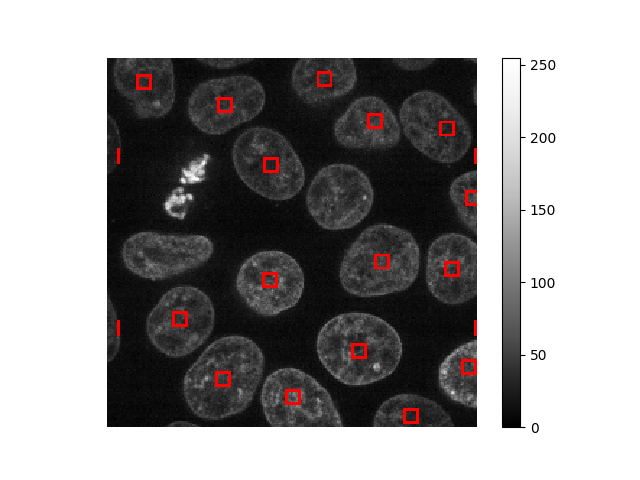
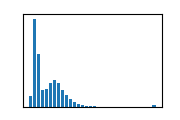

In [8]:
stackview.add_bounding_boxes(nuclei_uint8, bb_nuclei)

Uneven illumination or intensity bias can lead spot detectors (especially prompt-based or ML-based ones like Moondream) to focus only on the brightest region, ignoring fainter but still valid spots.

## High-content fluorescence microscopy dataset 

Malou Arvidsson, Salma Kazemi Rashed, & Sonja Aits. (2022). An annotated high-content fluorescence microscopy dataset with Hoechst 33342-stained nuclei and manually labelled outlines (Version 1) [Data set]. Zenodo. https://doi.org/10.5281/zenodo.6657260.

StackViewNDArray([[ 5,  8,  6, ...,  1,  1,  2],
                  [ 7, 10,  4, ...,  0,  1,  1],
                  [ 9,  6,  7, ...,  0,  0,  2],
                  ...,
                  [ 8,  6,  8, ..., 19, 23, 18],
                  [12,  8,  8, ..., 24, 21, 21],
                  [ 8,  7,  7, ..., 21, 19, 19]],
                 shape=(1104, 1104), dtype=uint8)
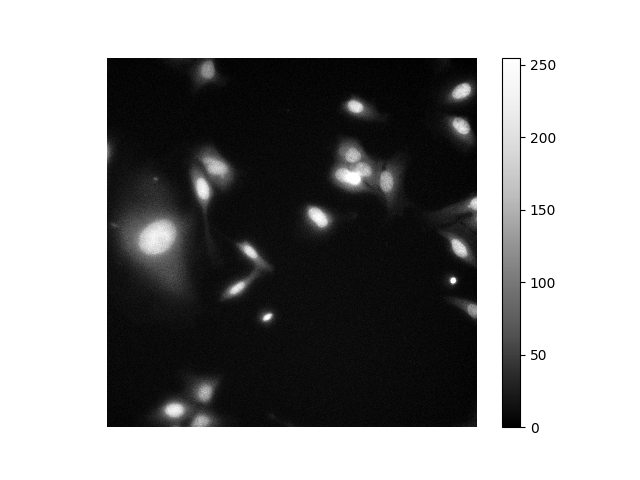
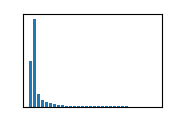

In [13]:
pil_cells = Image.open("MFGTMPcx7_170702000001_F11f10d0.png").convert("L")  # "L" = grayscale

# Convert to NumPy array
cells = np.array(pil_cells)
stackview.insight(cells)

In [14]:
encoded_cells = model.encode_image(pil_cells)

In [18]:
# Pointing
print("\nPointing: 'bright spot'")
points_cells = model.point(encoded_cells, "Mark the cells in the image, they have round bright nuclei and less bright cytoplasm. Please mark them in the center of the bright nuclei. If there are several nuclei very close to each other try to distinguish them as good as possible")["points"]
print(f"Found {len(points_cells)} bright spot(s)")


Pointing: 'bright spot'
Found 17 bright spot(s)


In [19]:
box_half_size_cells = 5 / cells.shape[0]
bb_cells = [{'x':p['x']-box_half_size_cells, 'y':p['y']-box_half_size_cells, 'width':2*box_half_size_cells, 'height':2*box_half_size_cells } for p in points_cells]

StackViewNDArray([[[ 5,  5,  5],
                   [ 8,  8,  8],
                   [ 6,  6,  6],
                   ...,
                   [ 1,  1,  1],
                   [ 1,  1,  1],
                   [ 2,  2,  2]],

                  [[ 7,  7,  7],
                   [10, 10, 10],
                   [ 4,  4,  4],
                   ...,
                   [ 0,  0,  0],
                   [ 1,  1,  1],
                   [ 1,  1,  1]],

                  [[ 9,  9,  9],
                   [ 6,  6,  6],
                   [ 7,  7,  7],
                   ...,
                   [ 0,  0,  0],
                   [ 0,  0,  0],
                   [ 2,  2,  2]],

                  ...,

                  [[ 8,  8,  8],
                   [ 6,  6,  6],
                   [ 8,  8,  8],
                   ...,
                   [19, 19, 19],
                   [23, 23, 23],
                   [18, 18, 18]],

                  [[12, 12, 12],
                   [ 8,  8,  8],
                   [ 8,  8,  8],
                   ...,
                   [24, 24, 24],
                   [21, 21, 21],
                   [21, 21, 21]],

                  [[ 8,  8,  8],
                   [ 7,  7,  7],
                   [ 7,  7,  7],
                   ...,
                   [21, 21, 21],
                   [19, 19, 19],
                   [19, 19, 19]]], shape=(1104, 1104, 3), dtype=uint8)
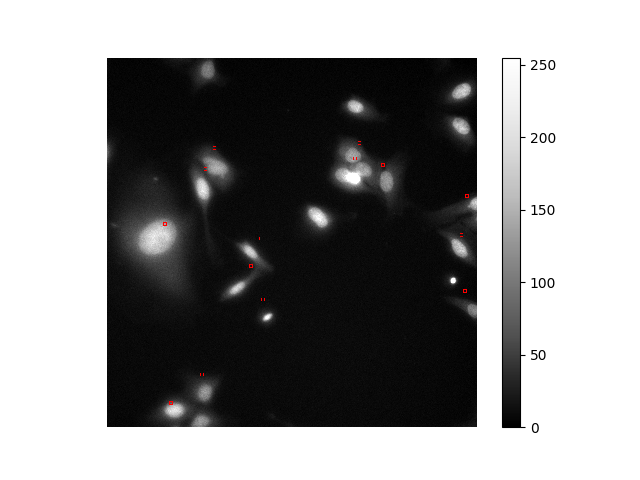
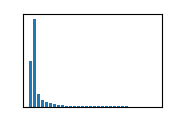

In [20]:
stackview.add_bounding_boxes(cells, bb_cells)

## Image with a large amount of objects

StackViewNDArray([[166, 165, 167, ..., 178, 182, 171],
                  [165, 161, 161, ..., 178, 171, 166],
                  [166, 164, 164, ..., 175, 164, 162],
                  ...,
                  [193, 193, 194, ..., 153, 156, 158],
                  [197, 196, 194, ..., 154, 159, 155],
                  [200, 198, 195, ..., 151, 157, 159]],
                 shape=(1200, 1600), dtype=uint8)
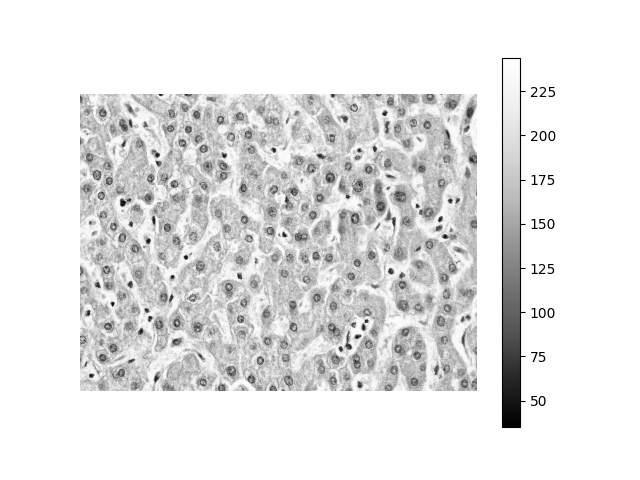
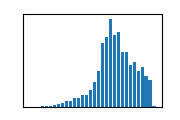

In [23]:
pil_histopathology = Image.open("K1180006.JPG").convert("L")  # "L" = grayscale

# Convert to NumPy array
histopathology = np.array(pil_histopathology)
stackview.insight(histopathology)

In [24]:
encoded_histopathology = model.encode_image(pil_histopathology)

In [25]:
print("\nPointing: 'bright spot'")
points_histopathology = model.point(encoded_histopathology, "Mark the dark round nuclei in the image")["points"]
print(f"Found {len(points_histopathology)} bright spot(s)")


Pointing: 'bright spot'
Found 50 bright spot(s)


In [26]:
box_half_size_histopathology = 5 / histopathology.shape[0]
bb_histopathology = [{'x':p['x']-box_half_size_histopathology, 'y':p['y']-box_half_size_histopathology, 'width':2*box_half_size_histopathology, 'height':2*box_half_size_histopathology } for p in points_histopathology]

StackViewNDArray([[[159, 159, 159],
                   [158, 158, 158],
                   [161, 161, 161],
                   ...,
                   [174, 174, 174],
                   [179, 179, 179],
                   [165, 165, 165]],

                  [[158, 158, 158],
                   [153, 153, 153],
                   [153, 153, 153],
                   ...,
                   [174, 174, 174],
                   [165, 165, 165],
                   [159, 159, 159]],

                  [[159, 159, 159],
                   [157, 157, 157],
                   [157, 157, 157],
                   ...,
                   [170, 170, 170],
                   [157, 157, 157],
                   [154, 154, 154]],

                  ...,

                  [[192, 192, 192],
                   [192, 192, 192],
                   [193, 193, 193],
                   ...,
                   [143, 143, 143],
                   [147, 147, 147],
                   [150, 150, 150]],

                  [[197, 197, 197],
                   [196, 196, 196],
                   [193, 193, 193],
                   ...,
                   [145, 145, 145],
                   [151, 151, 151],
                   [146, 146, 146]],

                  [[201, 201, 201],
                   [198, 198, 198],
                   [195, 195, 195],
                   ...,
                   [141, 141, 141],
                   [148, 148, 148],
                   [151, 151, 151]]], shape=(1200, 1600, 3), dtype=uint8)
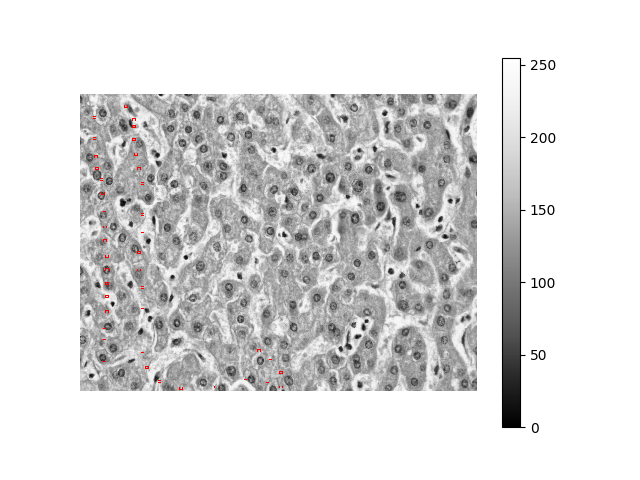
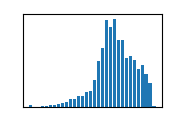

In [27]:
stackview.add_bounding_boxes(histopathology, bb_histopathology)